#Lista 1: Um pouco mais sobre CDFs, BoxPlots, histogramas...

## Forma de entrega

Baixe o ``.ipynb`` desse colab **com todas as suas respostas** e submeta o documento na atividade do AVA (apenas um integrante do grupo deve fazer a submissão -- quando for em grupo).


## Grupos

* **Graduação:** grupo de até 3 pessoas
* **Pós-Graduação:** individual

## Integrantes do grupo

1. **Nome(s):** Leonardo Silveira Kiepper

2. **Matrícula(s):** 2026140417

3. **E-mail(s) institucional(is):** leonardo.kiepper@edu.ufes.br

3. **Curso(s):** Doutorado em Ciência da Computação

4. **Link do seu Colab com suas soluções (para que o professor possa acessar e rodar o código):** https://colab.research.google.com/github/LeoKiepper/Ciencia-de-Dados/blob/main/lista_01.ipynb


## Sobre a Avaliação

Todas questões têm o mesmo peso/valor.

## Questão 1

O objetivo desta questão é comparar as **Funções de Distribuição** (i.e., CDF) teórica e empírica de algumas distribuições contínuas bem conhecidas.

Lembre-se que nós conversamos um pouco sobre CDFs na Aula 4.

### Exemplo

Vamos começar com um exemplo sobre a distribuição Uniforme contínua.

A biblioteca ``scipy`` possui funcionalidades para gerar números pseudo-aleatórios e para computar valores da CDF teórica da distribuição. Leia mais sobre em https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html.

A biblioteca ``statsmodels`` possui funcionalidades para computar a CDF empírica de um conjunto de observações.

In [44]:
from scipy.stats import uniform
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

In [45]:
def plot_uniform_cdf(loc, scale, n):
  # gera 'n' números de uma distribuição uniforme contínua no
  # intervalo [loc, loc + scale]
  r = uniform.rvs(loc = loc, scale = scale, size = n)

  # plota a CDF empírica dos números gerados
  cdf = ECDF(r)
  plt.plot(cdf.x, cdf.y, linewidth = 3, alpha = 0.5, color = 'blue',
           label = 'Empírica')

  # plota a CDF teórica de uma distribuição contínua uniforme no intervalo
  # [loc, loc + scale]
  plt.plot(cdf.x, uniform.cdf(cdf.x, loc = loc, scale = scale),
           alpha = 0.5, label = 'Teórica', color = 'red',
           linewidth = 3, zorder = 0);

  # Ajustes de rótulos e tamanho da figura...
  plt.legend(loc = 'best');
  plt.xlabel(r'$x$');
  plt.ylabel(r'CDF');
  plt.gcf().set_size_inches(3.5, 3.5)

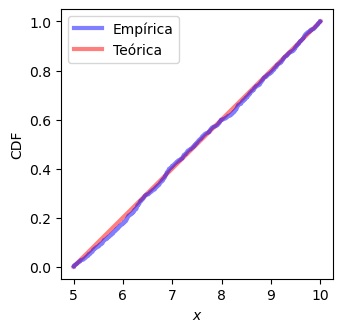

In [46]:
plot_uniform_cdf(5, 5, 1000)

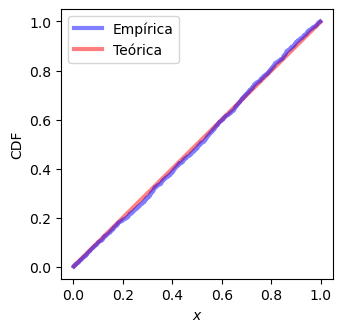

In [47]:
plot_uniform_cdf(0, 1, 1000)

### Parte (*a*)

Repita a análise acima para a distribuição normal. Lembre-se que a distribuição normal possui dois parâmetros: $\mu$ e $\sigma$.

Consulte https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html para gerar números pseudo-aleatórios e para computar a CDF da distribuição normal.

Você deve:
1. Completar a função abaixo para gerar gráficos comparativos entre as CDFs empíricas e teóricas da distribuição normal;
2. Executar seu código, variando os parâmetros da distribuição e número de elementos gerados.

In [48]:
from scipy.stats import norm

In [49]:
def plot_normal_cdf(mu, sigma, n):
  # A função fornecida para a plot de CDF da distribuição uniforme dá o esqueleto para essa função.
  
  ### === 1: Criar o handle para a amostragem da distribuição: 'r' 
  # Segundo a documentação da distribuição normal (https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html):
  #     """
  #        A normal continuous random variable.
  #        The location (loc) keyword specifies the mean. The scale (scale) keyword specifies the standard deviation.
  #     """
  #
  #     [... e dos exemplos de uso, verifica-se que o argumento size indica o número de amostras]
  #
  #     """
  #        Generate random numbers:
  #          >>> r = norm.rvs(size=1000)
  #     """
  # Assim, a correspondência dos argumentos desta função para o norm.rvs é:
  r = norm.rvs(loc=mu, scale=sigma, size=n)
  

  # Por preferência estilística, gerar todos os dados antes de plotar


  ### === 2: Amostragem
  # Passar o handle r para a função ECDF, importada acima, retorna a amostragem dos pontos.
  cdf_empirica = ECDF(r) 
  
  ### === 3: Obter a CDF teórica
  # Seguir a mesma correspondência de argumentos
  cdf_teorica = norm.cdf(cdf_empirica.x, loc = mu, scale = sigma)
  
  ### === 4: Plotagem
  plt.plot(cdf_empirica.x, cdf_empirica.y, 
    linewidth = 3, alpha = 0.5, color = 'blue', label = 'Empírica')
  plt.plot(cdf_empirica.x, cdf_teorica,
    alpha = 0.5, label = 'Teórica', color = 'red', linewidth = 3, zorder = 0)
  plt.legend(loc = 'best')
  plt.xlabel(r'$x$')
  plt.ylabel(r'CDF')
  plt.gcf().set_size_inches(3.5, 3.5)
  
  

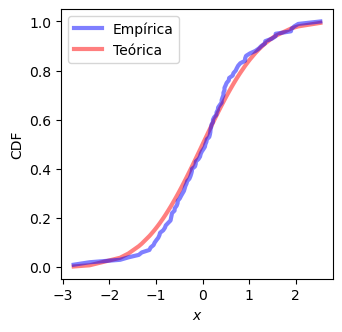

In [50]:
plot_normal_cdf(0, 1, 100)

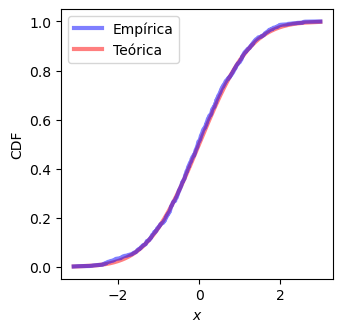

In [51]:
plot_normal_cdf(0, 1, 1000)

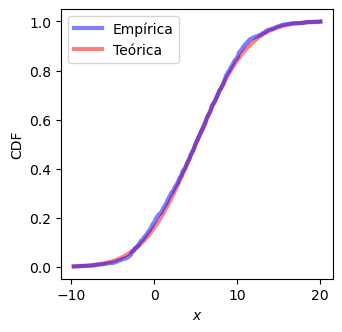

In [52]:
plot_normal_cdf(5, 5, 1000)

### Parte (*b*)

Repita a análise inicial para a distribuição exponencial. Lembre-se, dado um parâmetro $\lambda > 0$, a densidade da distribuição exponencial é:
$$f(x) = \lambda e^{-\lambda x}\text{, } x > 0.$$

Consulte https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html para gerar números pseudo-aleatórios e para computar a CDF da distribuição exponencial.

Você deve:
1. Completar a função abaixo para gerar gráficos comparativos entre as CDFs empíricas e teóricas da distribuição exponencial;
2. Executar seu código, variando os parâmetros da distribuição e número de elementos gerados.

**ATENÇÃO:** Leia com atenção a documentação da biblioteca mencionada para entender como o parâmetro $\lambda$ deve ser fornecido. O $\lambda$ da definição acima não é o mesmo que o `scale` da biblioteca.

In [53]:
from scipy.stats import expon

In [54]:
def plot_exponential_cdf(lambda_, n):
  # Criar mais uma função outra distribuição é questão de seguir o mesmo processo de antes.
    
  ### === 1: Criar o handle para a amostragem da distribuição: 'r' 
  # Segundo a documentação da distribuição normal (https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html):
  #     """
  #       A common parameterization for expon is in terms of the rate parameter lambda,
  #       such that pdf = lambda * exp(-lambda * x). 
  #       This parameterization corresponds to using scale = 1 / lambda.
  #     """
  #
  #     [... assim como na distribuição normal, e todas as outras distribuições:
  #       dos exemplos de uso, verifica-se que o argumento size indica o número de amostras]
  #
  #     """
  #        Generate random numbers:
  #          >>> r = expon.rvs(size=1000)
  #     """
  # Assim, a correspondência dos argumentos desta função para o norm.rvs é:
  r = expon.rvs(loc=0, scale=1/lambda_, size=n)
  

  # Por preferência estilística, gerar todos os dados antes de plotar


  ### === 2: Amostragem
  # Passar o handle r para a função ECDF, importada acima, retorna a amostragem dos pontos.
  cdf_empirica = ECDF(r) 
  
  ### === 3: Obter a CDF teórica
  # Seguir a mesma correspondência de argumentos
  cdf_teorica = expon.cdf(cdf_empirica.x, loc = 0, scale = 1/lambda_)
  
  ### === 4: Plotagem
  plt.plot(cdf_empirica.x, cdf_empirica.y, 
    linewidth = 3, alpha = 0.5, color = 'blue', label = 'Empírica')
  plt.plot(cdf_empirica.x, cdf_teorica,
    alpha = 0.5, label = 'Teórica', color = 'red', linewidth = 3, zorder = 0)
  plt.legend(loc = 'best')
  plt.xlabel(r'$x$')
  plt.ylabel(r'CDF')
  plt.gcf().set_size_inches(3.5, 3.5)
  


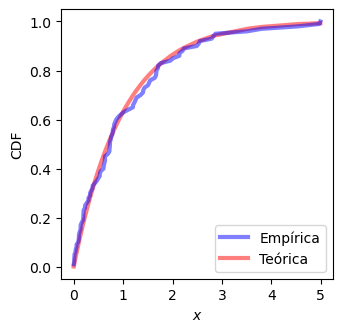

In [55]:
plot_exponential_cdf(1, 100)

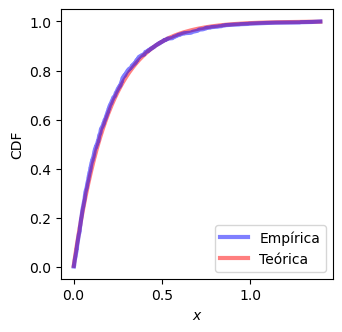

In [56]:
plot_exponential_cdf(5, 1000)


### Parte (*c*)

Agora as coisas ficam mais interessantes...

Repita a análise inicial para a distribuição de pareto. Lembre-se, dado um parâmetro $b > 0$, a densidade da distribuição de pareto é:
$$f(x) = \frac{b}{x^{b+1}}\text{, } x \ge 1.$$

Consulte https://docs.scipy.org/doc/scipy/tutorial/stats/continuous_pareto.html para gerar números pseudo-aleatórios e para computar a CDF da distribuição de pareto.

Você deve:
1. Completar a função abaixo para gerar gráficos comparativos entre as CDFs empíricas e teóricas da distribuição de pareto;
2. Executar seu código, variando os parâmetros da distribuição e número de elementos gerados.

In [57]:
from scipy.stats import pareto

In [58]:
def plot_pareto_cdf(b, n):
  # Criar mais uma função outra distribuição é questão de seguir o mesmo processo de antes.
    
  ### === 1: Criar o handle para a amostragem da distribuição: 'r' 
  # No caso da distribuição de pareto, (https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pareto.html#scipy.stats.pareto):
  # o argumento 'b' é passado com o mesmo nome
  r = pareto.rvs(b=b, size=n)
  

  # Por preferência estilística, gerar todos os dados antes de plotar


  ### === 2: Amostragem
  # Passar o handle r para a função ECDF, importada acima, retorna a amostragem dos pontos.
  cdf_empirica = ECDF(r) 
  
  ### === 3: Obter a CDF teórica
  # Seguir a mesma correspondência de argumentos
  cdf_teorica = pareto.cdf(cdf_empirica.x, b = b)
  
  ### === 4: Plotagem
  plt.plot(cdf_empirica.x, cdf_empirica.y, 
    linewidth = 3, alpha = 0.5, color = 'blue', label = 'Empírica')
  plt.plot(cdf_empirica.x, cdf_teorica,
    alpha = 0.5, label = 'Teórica', color = 'red', linewidth = 3, zorder = 0)
  plt.legend(loc = 'best')
  plt.xlabel(r'$x$')
  plt.ylabel(r'CDF')
  plt.gcf().set_size_inches(3.5, 3.5)
  


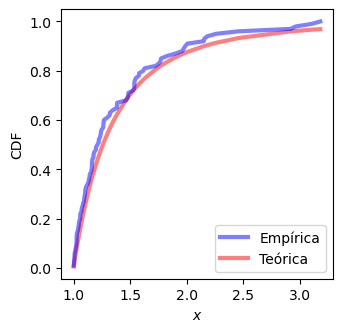

In [59]:
plot_pareto_cdf(3, 100)

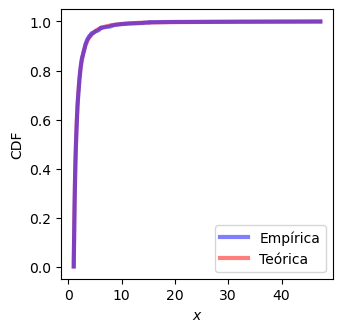

In [60]:
plot_pareto_cdf(2, 1000)

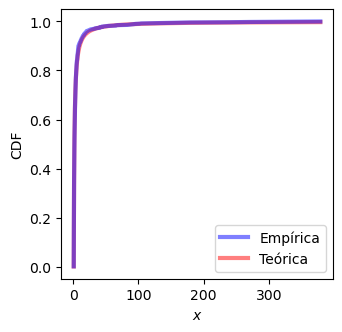

In [61]:
plot_pareto_cdf(1, 1000)

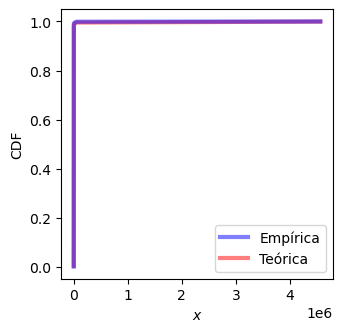

In [62]:
plot_pareto_cdf(0.5, 1000)

Após fazer as figuras, você provavelmente observou que para valores pequenos de $b$, a CDF da distribuição de pareto é bastante difícil de ler, uma vez que fica praticamente "colada" às retas $x = 0$ e $y = 1$.

Esse fenômeno ocorre porque, quando $b$ é pequeno, valores muito grandes (i.e., discrepantes ou *outliers*) têm uma probabilidade não negligível de ocorrerem.

Quando observamos o comportamento das figuras acima, devemos modificar a forma de visualizar a distribuição:
1. Devemos gerar uma figura para a CCDF (*Complementary Cumulative Distribution Function*). A CCDF de um valor $x$ é definida como 1 menos a CDF de $x$.
2. Devemos colocar os eixos $x$ e $y$ em escala logarítmica.

Complete a função abaixo para gerar a figura da forma descrita acima e gere os gráficos para os mesmos casos que testou anteriormente.

In [63]:
def plot_pareto_ccdf(b, n):
  # Tomando como base a função 'plot_pareto_cdf':
    
  ### === 1: Criar o handle para a amostragem da distribuição: 'r' 
  # No caso da distribuição de pareto, (https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pareto.html#scipy.stats.pareto):
  # o argumento 'b' é passado com o mesmo nome
  r = pareto.rvs(b=b, size=n)
  

  # Por preferência estilística, gerar todos os dados antes de plotar


  ### === 2: Amostragem
  # Passar o handle r para a função ECDF, importada acima, retorna a amostragem dos pontos.
  ccdf_empirica = (cdf_empirica := ECDF(r))
  ccdf_empirica.y = 1 - ccdf_empirica.y
  
  ### === 3: Obter a CDF teórica
  # Seguir a mesma correspondência de argumentos
  ccdf_teorica = (cdf_teorica := pareto.cdf(cdf_empirica.x, b = b))
  ccdf_teorica = 1 - ccdf_teorica
  
  ### === 4: Plotagem
  plt.plot(ccdf_empirica.x, ccdf_empirica.y, 
    linewidth = 3, alpha = 0.5, color = 'blue', label = 'Empírica')
  plt.plot(ccdf_empirica.x, ccdf_teorica,
    alpha = 0.5, label = 'Teórica', color = 'red', linewidth = 3, zorder = 0)
  plt.legend(loc = 'best')
  plt.xlabel(r'$x$')
  plt.ylabel(r'CCDF')
  plt.gcf().set_size_inches(3.5, 3.5)
  # Modifica os eixos para escala logaritmica
  plt.gca().set(xscale='log', yscale='log')
  


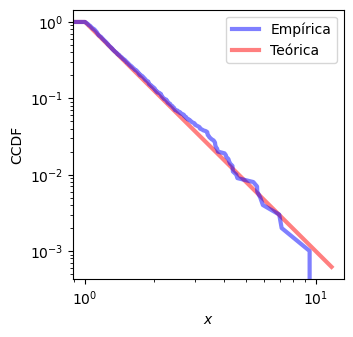

In [64]:
plot_pareto_ccdf(3, 1000)

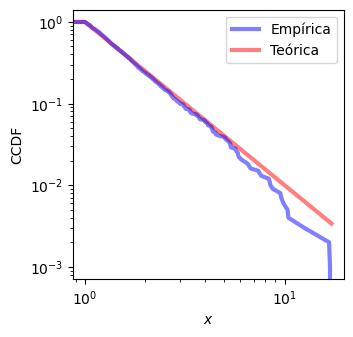

In [65]:
plot_pareto_ccdf(2, 1000)

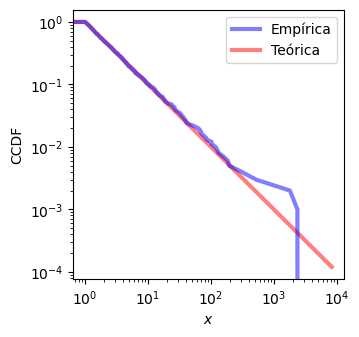

In [67]:
plot_pareto_ccdf(1, 1000)

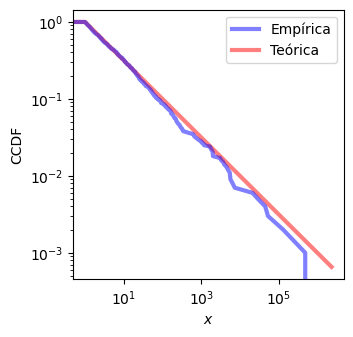

In [68]:
plot_pareto_ccdf(0.5, 1000)

## Questão 2

Esta questão é **obrigatória** apenas para alunos da **pós-graduação**.

O objetivo desta questão é entender o comportamento da **parte (*c*)** da questão anterior.

Você deve ler as duas primeiras seções do artigo https://arxiv.org/pdf/cond-mat/0412004.pdf e fazer um resumo (de no máximo uma página). Certifique-se de incluir no seu resumo, entre outras informações que achar relevantes, o motivo de a CCDF da distribuição de pareto ter a forma que tem quando ambos os eixos estão em escala logarítmica.

A PDF de Pareto é dada pela equação $f(x) = \frac{b}{x^{b+1}}$. Conforme explicado por Newman, a CCDF de distribuições cuja PDF é da forma $p(x)=Cx^{-\alpha}$ é $$ P(x)=\frac{C}{\alpha-1}x^{-(\alpha-1)} $$ 
Note que aqui, Newman fala da CCDF, pois ele define $P(x)$ como a probabilidade da variável assumir um valor ***maior ou igual*** a $x$. Em contraste, a CDF é a probabilidade da variável aletória assumir um valor ***menor ou igual*** a $x$. Isso necessariamente significa que $P(x)$ é complementar à CDF, que é o que os códigos acima produzem, e por isso é feita a operação
```python
  ccdf_empirica = (cdf_empirica := ECDF(r))
  # [e mais adiante]  
  ccdf_teorica = 1 - ccdf_teorica

```



No caso da distribuição de Pareto, que se enquadra nessa forma, $\alpha=b+1$ e $ P(x)=\frac{C}{b}x^{-b}$. Como consequência, o expoente $-b$ leva o log de $P(x)$ a se assemelhar a uma linha reta com inclinação negativa. Isto é: $$\log{P(x)}=\log{C}-\log{b}-b\cdot\log{x}$$
Assim os dados plotados da CCDF no plot log-log ficam na forma $$y=c_0-c_1\cdot x$$


## Questão 3

Primeiro, você deve ler os artigos abaixo.
1. [Common pitfalls in statistical analysis: The use of correlation techniques](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5079093/)
2. [Chocolate Consumption, Cognitive Function,
and Nobel Laureates](https://www.nejm.org/doi/full/10.1056/NEJMon1211064)

Resumindo o que foi lido nos artigos, responda as seguintes questões:

1. O que é o coeficiente de correlação?
2. Quando o coeficiente de correlação é útil e quando ele pode ser a ferramenta errada para analisar a relação entre duas variáveis?
3. Qual a diferença entre causalidade e correlação?

**Observação 1:** é esperado que a resposta das três perguntas utilize aproximadamente duas páginas A4.

**Observação 2:** você pode consultar outras fontes para responder as questões acima. No entanto, é esperado que as respostas sejam no contexto do conteúdo dos artigos.

## O que é coeficiente de correlação?
O *coeficiente de correlação* $r$ entre duas variáveis expressa quão interligadas elas estão, no sentido de suas variações acontecerem juntas num determinado *dataset* sendo observado. É conhecido também como coeficiente de correlação de Pearson. É positivo quando as mudanças na variável A provocam variações em B com o mesmo sinal, e é negativo quando o sinal das variações é oposto. Sua utilidade é para quantificar essa interligação. Quando atentados os requisitos matemáticos que garantem que o coeficiente de correlação pode ser usado (veja os erros comuns 2 e 3), e tomadas precauções para eliminar interpretações espúrias (erros 4, 5 e 6), $r$ é um único número que descreve bem o comportamento linear de um grupo de observações, isto é, considerando variáveis lineares **contínuas**, e com uma tendência linear. No entanto, o *coeficiente de determinação* $R^2$ é preferível e mais usado na prática (em ciências exatas), porque carrega um significado mais útil em estatística: $R^2$ quantifica quanto a variação de uma variável pode ser atribuída a variação em outra variável.

O coeficiente $r$ é definido no intervalo $r \in[-1,1]$, e é uma propriedade do conjunto de pontos. Quando o módulo $|r|=1$ entre duas variáveis, os pontos de dados do dataset encontram-se exatamente sobre uma linha reta ligando as variáveis correlacionadas.

#### Erros na consideração de $r$, ou quando não usar
1. **Confundir correlação com causalidade.** A leitura estatística correta, quando uma correlação é observada, é que (i) uma variável A interfere em B diretamente (por exemplo, incidência de chuva e temperatura média no dia), ou (ii) A e B compartilham interferência a partir de uma terceira variável C (por exemplo, consumo de chocolate e "chance" de ganhar o prêmio Nobel, que na verdade são ambos influenciados pela renda per capita). Causalidade ***pode*** existir entre A e B no caso (i), mas não no caso (ii). Dito isso, causalidade significa que variações numa variável "sempre" *causam* variações em outra (isto é, a distribuição de probabilidade de A afeta a distribuição de B). Estatisticamente, isso significa que causalidade é uma hipótese falsificável. Suponha que deseja-se saber se variações na variável A *causam* variações na variável B. Observar, no *dataset*, que A varia sem que B tenha variado junto, falsifica a causalidade A $\rightarrow$ B.
2. **Atribuir correlação entre variáveis que não se relacionam linearmente.** O coeficiente de correlação é aplicável somente a variáveis que se relacionam linearmente. Isso leva a uma dica interessante. Se for observado que a variável B demonstra "correlação" com o quadrado da variável A, a correlação não pode ser usada diretamente, mas nada impede que se defina uma quantidade proporcional ao quadrado de A, digamos A2, e assim a correlação A2 $\leftrightarrow$ B faz sentido matematicamente.
3. **Assumir que as observações sao independentes, quando não são, ou uma variável é parte de um todo expresso em outra variável.** A observação de correlação é espúria se duas observações forem dependentes. Por exemplo, a altura total de uma pessoa terá correlação forte com o comprimento das pernas, mas isso acontece porque as pernas sempre são parte importante (e principalmente, aproximadamente proporcional) da altura.
4. **Não dividir a análise por subgrupo.** Se um dataset estiver *clusterizado* em regiões que se posicionem aproximadamente numa reta, $r$ pode ser espúrio se não for semelhante dentro de cada subgrupo (por exemplo altura x nível de hemoglobina, que se agrupa em dois *clusters* de homens x mulheres). 
5. **Não remover outliers.** Explicável pelo mesmo motivo dos subgrupos. A presença de um outlier (que necessariamente se situa longe de um agrupamento de pontos) altera significativamente o $r$.
6. **Atribuir correlação entre variáveis não contínuas.** O coeficiente de correlação $r$ é aplicável a variáveis contínuas. Para outros domínios, outros coeficientes são análogos, por exemplo o coeficiente de correlação de postos de Spearman, $\rho$, para variáveis ordinárias.
6. ***Datasets* muito pequenos.** Quando há poucos pontos no dataset, é fácil que $r$ seja alto, mas isso não significa necessariamente que o $r$ medido permaneceria alto num dataset maior amostrando a mesma população.
7. **Heterocedasticidade.** Nem sempre uma variável terá uma distribuição homogênea, e a variância muda com a magnitude da variável. Por exemplo, o gasto com saúde pode variar muito com a renda percapta. Pessoas mais pobres têm menos renda disponível, então o gasto com saúde é limitado. Em contrapartida, o gasto com saúde de uma pessoa rica é determinada mais pelas particularidades individuais do que pela renda percapta.


#### Curiosidade matemática
Se, na fronteira do domínio para o qual $r$ é definido (isto é, $|r|=1$), o local geométrico dos pontos é necessariamente uma reta, então que reta é essa? **É a reta de mínimos quadrados.**
> ##### **Demonstração**
> **Afirmação.** Se $|r| = 1$, os pontos $(x_i, y_i)$ estão todos sobre a reta de mínimos quadrados, cuja inclinação $\pm\,s_y/s_x$ pode ter qualquer módulo não nulo.
>
> Sejam $s_x^2 = \frac1n\sum_i (x_i - \bar x)^2$ e $s_y^2$ as variâncias amostrais de $x$ e $y$ (ambas $> 0$), $c_{xy} = \frac1n\sum_i (x_i - \bar x)(y_i - \bar y)$ a covariância amostral (SHALIZI, 2025, p. 36, eqs. 2.1–2.2) e $r = c_{xy}/(s_x s_y)$ a correlação. Para uma reta $y = a + bx$, seja $Q(a,b) = \sum_i (y_i - a - bx_i)^2$ o erro quadrático, e $S_{yy} = \sum_i (y_i - \bar y)^2 = n s_y^2$. Usamos dois fatos-padrão da regressão linear simples:
> 1. A reta de mínimos quadrados $y = a^* + b^*x$ é o único minimizador de $Q$ (SHALIZI, 2025, p. 53, §4.2.1), com $b^* = c_{xy}/s_x^2$ (p. 36, eq. 2.3); logo $b^* = \dfrac{c_{xy}}{s_x s_y}\cdot\dfrac{s_y}{s_x} = r\,\dfrac{s_y}{s_x}$.
> 2. Seu coeficiente de determinação é $R^2 = (s_y^2 - \hat\sigma^2)/s_y^2$, onde $\hat\sigma^2 = \frac1n\sum_i (y_i - a^* - b^*x_i)^2 = Q(a^*,b^*)/n$ (p. 61, eq. 4.50; p. 180, eq. 10.9); portanto $R^2 = 1 - Q(a^*,b^*)/S_{yy}$. Além disso $R^2 = \big(c_{xy}/(s_x s_y)\big)^2 = r^2$ (p. 180, eq. 10.8).
>
> Suponha $|r| = 1$ e que algum ponto $(x_k, y_k)$ **não** está sobre a reta de mínimos quadrados, isto é, $y_k \neq a^* + b^*x_k$. Em $Q(a^*,b^*)$ todas as parcelas são quadrados, logo $\ge 0$, e a parcela $i = k$ é estritamente positiva:
>
> $$Q(a^*,b^*) = \underbrace{(y_k - a^* - b^*x_k)^2}_{>\,0} + \sum_{i \neq k} \underbrace{(y_i - a^* - b^*x_i)^2}_{\ge\,0} > 0 .$$
>
> Como $S_{yy} > 0$, segue $Q(a^*,b^*)/S_{yy} > 0$ e, pelo fato 2, $R^2 = 1 - Q(a^*,b^*)/S_{yy} < 1$. Mas $|r| = 1$ dá $r^2 = 1$, e o fato 2 exige $R^2 = r^2 = 1$. Contradição. Portanto todos os pontos estão sobre a reta de mínimos quadrados, cuja inclinação $b^* = r\,s_y/s_x = \pm\,s_y/s_x$ tem o sinal de $r$ e módulo arbitrário — a razão entre as dispersões de $y$ e de $x$.
>
> *Recíproca.* Se os pontos estão sobre uma reta $L$ de inclinação $b \neq 0$, então $Q(L) = 0 \le Q(a^*,b^*)$; pela unicidade (fato 1), $L$ é a reta de mínimos quadrados, e $r^2 = R^2 = 1 - 0 = 1$. $\blacksquare$
>
> A equivalência "$R^2 = 1$ $\Leftrightarrow$ todos os pontos sobre uma reta" é demonstrada em SHALIZI (2025, p. 181, parágrafo *Limits for $R^2$*).
>
> ##### **Referência**
> SHALIZI, Cosma Rohilla. **The truth about linear regression**. Pittsburgh: Carnegie Mellon University, 2025. Disponível em: https://www.stat.cmu.edu/~cshalizi/TALR/TALR.pdf. Acesso em: 29 ago. 2026.


## Questão 4

Obtenha o conjunto de dados disponível no AVA da disciplina para essa questão. O conjunto de dados possui duas colunas: `type` e `score`. Você pode pensar nesses dados como sendo o resultados de medições (`score`) realizadas em um conjunto de objetos que pode ser de três tipos diferentes (`type`).

### Parte (a)

Leia o conjunto de dados e armazene-o em um `DataFrame` do `Pandas`.

In [69]:
import pandas as pd
df = pd.read_csv('dados_questao_4.csv')
print(len(df))
df.head()



14851


,score,type
0,0.023120,A
1,0.870633,A
2,-0.051788,A
3,0.490284,A
4,-0.296330,A


### Parte (b)

Usando a biblioteca `seaborn`, Faça o *BoxPlot* da variável `score` para todos os objetos, independentemente do tipo.

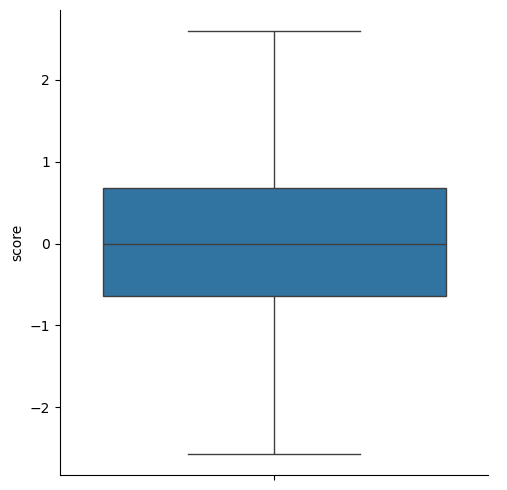

In [70]:
import seaborn as sns
sns.catplot(y='score',kind="box", data=df)

Agora, faça, em uma mesma figura, os *BoxPlots* para a variável `score` de acordo com a variável `type`. Isto é, um *BoxPlot* da variável `score` para cada valor de `type`. Novamente, use a biblioteca `seaborn`.

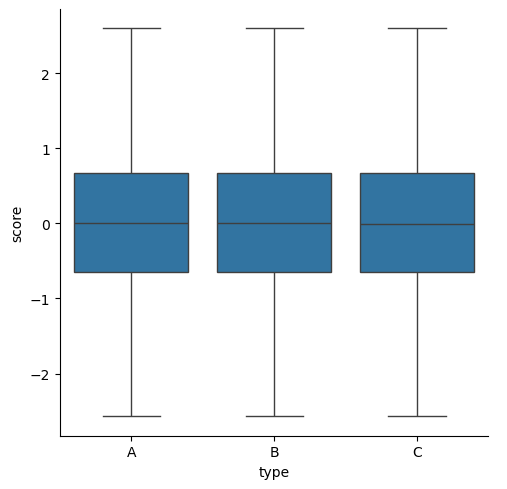

In [71]:
sns.catplot(x="type", y="score", kind="box", data=df)

Com base **apenas** nos *BoxPlots*, o que é possível afirmar sobre a dispersão/distribuição dos dados das três variáveis? Você diria que as três distribuições são similares?

Sim. O segundo *BoxPlot* mostra exatamente a mesma dispersão para cada tipo: Mesmos quartis, medianas, máximo e mínimo.


### Parte (c)

Agora:

1. Repita a Parte (b), mas agora, ao invés de fazer os *BoxPlots*, faça os histogramas.

2. Repita a Parte (b), mas agora, ao invés de fazer os *BoxPlots*, faça as CDFs empíricas (vide Questão 1).

3. Repita a Parte (b), mas agora, ao invés de fazer os *BoxPlots*, faça os gráficos de Violino.



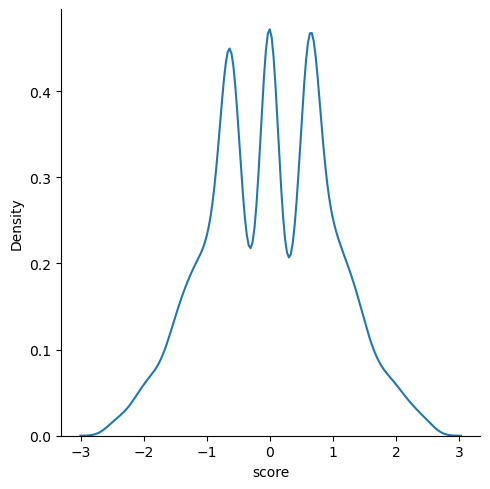

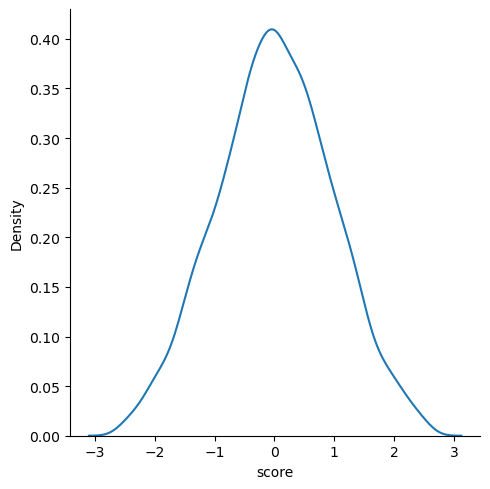

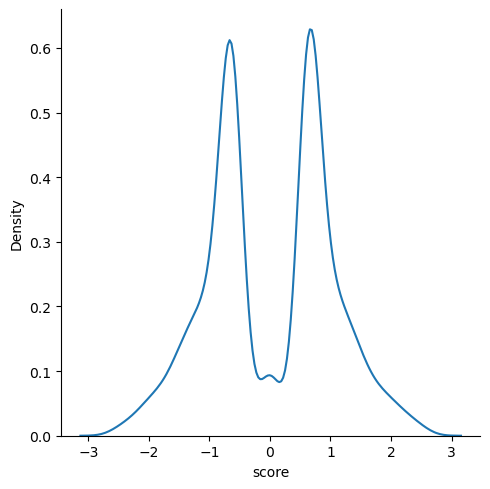

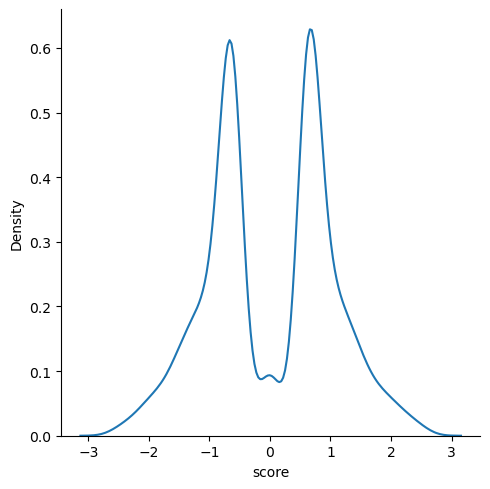

In [72]:
sns.displot(df, x="score", kind="kde")
sns.displot(df[df.type=='A'], x="score", kind="kde")
sns.displot(df[df.type=='B'], x="score", kind="kde")
sns.displot(df[df.type=='B'], x="score", kind="kde")

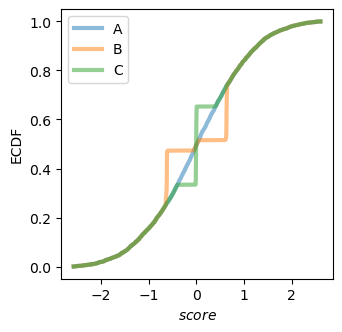

In [73]:
from statsmodels.distributions.empirical_distribution import ECDF
import numpy as np
def plot_ecdf(df):
  for tt in df['type'].unique():
    ecdf = ECDF(df[df.type==tt].score)   
    plt.plot(ecdf.x, ecdf.y, linewidth = 3, alpha = 0.5,
            label = tt)

  plt.legend(loc = 'best');
  plt.xlabel(r'$score$');
  plt.ylabel(r'ECDF');
  plt.gcf().set_size_inches(3.5, 3.5)
  
plot_ecdf(df)
# sns.ecdfplot(data=df, x='score', hue='type')

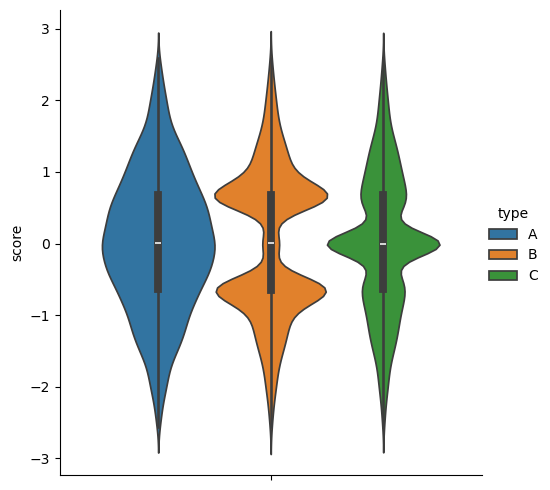

In [74]:
 sns.catplot(hue="type", y="score", kind="violin", data=df)

Revisitando a conclusão da Parte (b)...

Com base nessas novas figuras, o que é possível dizer sobre a dispersão/distribuição das três variáveis? Você diria que as três distribuições são similares?

Os histogramas dão a entender que as distribuições de B e C são identicas e A é diferente, mas o ECDF mostra que cada dispersão é diferente. O plot violino suporta a conclusão do ECDF.

## Questão 5

Ainda no espírito das duas questões anteriores.

Leia o conjunto de dados, disponível no AVA, para a Questão 5 e carregue os dados em um `DataFrame` do `Pandas`. O arquivo contém um conjunto de pontos no plano, ou seja, uma coleção de pares ($x$, $y$).

Na verdade, o arquivo é uma coleção de vários conjuntos de dados. O arquivo possui três colunas:
- `dataset` indica a qual conjunto de dados um ponto pertence
- `x` indica a coordenada $x$ de cada ponto do conjunto
- `y` indica a coordenada $y$ de cada ponto do conjunto



### Parte (a)

Para cada um dos 13 conjuntos de dados disponível no arquivo, calule e imprima:
1. A média dos valores das colunas `x` e `y`
2. O desvio padrão dos valores das colunas `x` e `y`
3. A correlação linear entre as colunas `x` e `y`

Com base nos valores observados, formule uma hipótese sobre o grau de similaridade entre os diversos conjuntos de dados. Em outras palavras, vocês diriam que eles são similares ou diferentes?

**Observação:** tente modularizar seu código e utilizar os recursos do `Pandas`, por exemplo, `groupby`.

### Parte (b)

Agora, vamos testar a hipótese estabelecida no item anterior. Faça um gráfico, para cada um dos 13 conjuntos de dados, marcando os pontos de cada conjunto no plano.

Com base nos gráficos, o que pode ser dito sobre o grau de similaridade entre os diversos conjuntos de dados? Em outras palavras, vocês diriam que eles são similares ou diferentes?

## Referências (Spoiler Alert!)

Os dados de algumas questões foram obtidos em https://www.research.autodesk.com/publications/same-stats-different-graphs/. Para não estragar a surpresa, sugiro consultar essa referência apenas após tentar resolver as questões. De toda forma, as respostas das perguntas não estão contidas na página citada.

## Leitura Recomendada (não vale pontos e não é necessário entregar)

Quer entender um pouco mais sobre a **história** e o **início** das ferramentas para processamento de grandes bases de dados?

1. MapReduce (2004) https://www.cs.princeton.edu/courses/archive/fall13/cos518/papers/mapreduce.pdf

2. HDFS (2007) https://www.cs.stolaf.edu/docs/hadoop/hdfs_design.pdf

3. Spark (2012) https://www.usenix.org/system/files/conference/nsdi12/nsdi12-final138.pdf

# Referências das respostas

- James, G., Witten, D., Hastie, T. & Tibshirani, R. *An Introduction to Statistical Learning*, 2ª ed., Springer, 2021. §3.1.3: na regressão linear simples, $R^2 = r^2$. PDF liberado pelos autores: <https://www.statlearning.com/>
- Hastie, T., Tibshirani, R. & Friedman, J. *The Elements of Statistical Learning*, 2ª ed., Springer, 2009. §3.2: mínimos quadrados como projeção ortogonal. PDF liberado com autorização da Springer: <https://hastie.su.domains/ElemStatLearn/>
- Shalizi, C. R. *The Truth About Linear Regression* (notas, CMU). Cap. 1 "Optimal prediction" (melhor preditor linear, $\beta = \mathrm{Cov}(X,Y)/\mathrm{Var}(X)$) e cap. 4 "The method of least squares for simple linear regression". <https://www.stat.cmu.edu/~cshalizi/TALR/>
- Blitzstein, J. & Hwang, J. *Introduction to Probability*, 2ª ed., CRC, 2019. §7.3 ($-1 \le \mathrm{Corr}(X,Y) \le 1$) e cap. 9 (exemplo "linear regression": versão populacional). PDF liberado pelos autores: <https://probabilitybook.net/>
- Wikipedia, "Simple linear regression", seção "Relationship with the sample covariance matrix": $\hat\beta = r_{xy}\,s_y/s_x$ e $R^2 = r_{xy}^2$. <https://en.wikipedia.org/wiki/Simple_linear_regression>